<a href="https://colab.research.google.com/github/LleilaA13/Thesis-MUL/blob/master/notebooks/resnettutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Licensed under the Apache License, Version 2.0 (the "License");

In [38]:
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

<img src="https://raw.githubusercontent.com/greentfrapp/lucent/master/images/lucent_header.jpg" width="600"></img>

# Lucent Tutorial

A Colab notebook following the spirit of Lucid's notebooks.



## Install, Import, Load Model

In [39]:
!pip install --quiet git+https://github.com/greentfrapp/lucent.git

  Preparing metadata (setup.py) ... done


In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
import torch
from torchvision import models
import matplotlib.pyplot as plt
import torchvision.transforms as T
from lucent.modelzoo.util import get_model_layers
from lucent.optvis import render, param, transform, objectives

def load_resnet18(path):
    model = models.resnet18(num_classes=10)
    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    try:
        model.load_state_dict(checkpoint['state_dict'], strict=False)
    except:
        model.load_state_dict(checkpoint, strict=False)
    model.eval()
    return model

original_model = load_resnet18("/content/drive/MyDrive/THESIS/0checkpoint.pth.tar")
unlearned_model = load_resnet18("/content/drive/MyDrive/THESIS/RLcheckpoint.pth.tar")

Available layers in the model:
['conv1', 'bn1', 'relu', 'maxpool', 'layer1', 'layer1_0', 'layer1_0_conv1', 'layer1_0_bn1', 'layer1_0_relu', 'layer1_0_conv2', 'layer1_0_bn2', 'layer1_1', 'layer1_1_conv1', 'layer1_1_bn1', 'layer1_1_relu', 'layer1_1_conv2', 'layer1_1_bn2', 'layer2', 'layer2_0', 'layer2_0_conv1', 'layer2_0_bn1', 'layer2_0_relu', 'layer2_0_conv2', 'layer2_0_bn2', 'layer2_0_downsample', 'layer2_0_downsample_0', 'layer2_0_downsample_1', 'layer2_1', 'layer2_1_conv1', 'layer2_1_bn1', 'layer2_1_relu', 'layer2_1_conv2', 'layer2_1_bn2', 'layer3', 'layer3_0', 'layer3_0_conv1', 'layer3_0_bn1', 'layer3_0_relu', 'layer3_0_conv2', 'layer3_0_bn2', 'layer3_0_downsample', 'layer3_0_downsample_0', 'layer3_0_downsample_1', 'layer3_1', 'layer3_1_conv1', 'layer3_1_bn1', 'layer3_1_relu', 'layer3_1_conv2', 'layer3_1_bn2', 'layer4', 'layer4_0', 'layer4_0_conv1', 'layer4_0_bn1', 'layer4_0_relu', 'layer4_0_conv2', 'layer4_0_bn2', 'layer4_0_downsample', 'layer4_0_downsample_0', 'layer4_0_downsample

100%|██████████| 512/512 [01:39<00:00,  5.12it/s]



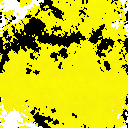

100%|██████████| 512/512 [01:25<00:00,  5.99it/s]



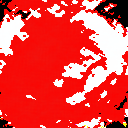

In [42]:
from lucent.modelzoo.util import get_model_layers
from lucent.optvis import render, param, transform, objectives

print("Available layers in the model:")
print(get_model_layers(original_model))

print("Available layers in the model:")
print(get_model_layers(unlearned_model))

# Example: visualizing filters from conv1
# Added show_inline=True to display the visualizations
_ = render.render_vis(original_model, "conv1:0", show_inline=True)
_ = render.render_vis(unlearned_model, "conv1:0", show_inline=True)

100%|██████████| 512/512 [03:16<00:00,  2.60it/s]



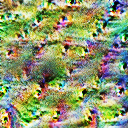

100%|██████████| 512/512 [03:18<00:00,  2.58it/s]



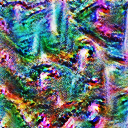

In [53]:
_ = render.render_vis(original_model, "layer4_1_conv1:0", show_inline=True)
_ = render.render_vis(unlearned_model, "layer4_1_conv1:0", show_inline=True)

Similar to [Lucid](https://github.com/tensorflow/lucid/), this tutorial will be focused on the same InceptionV1 model, also known as GoogLeNet.

Check out the original GoogLeNet paper [here](https://research.google.com/pubs/archive/43022.pdf).

[Distill](https://distill.pub) also has a fascinating [article](https://distill.pub/2017/feature-visualization/) on this topic that includes visualizations of all the InceptionV1 neurons.


`render_vis` has a few nice defaults so we can get started quickly!

## Fiddling with the Knobs

Just like Lucid, Lucent splits visualizations into *objectives*, *parameterizations* and *transforms*. To quote from Lucid's tutorial:

* **Objectives** -- What do you want the model to visualize?
* **Parameterizations** -- How do you describe the image?
* **Transforms** -- What transformations do you want your visualization to be robust to?

### Objectives

What loss function do we want to minimize?

Or from another point of view, what part of the model do we want to understand?

In essence, we are trying to generate an image that causes a particular neuron or filter to activate strongly. The objective allows us to select a specific neuron, channel or a mix!

100%|██████████| 512/512 [02:33<00:00,  3.34it/s]



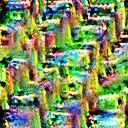

In [43]:
# The default is optimizing for a channel/filter
obj = objectives.channel("layer3_1_conv2", 10)
# Added show_inline=True to display the visualization
_ = render.render_vis(original_model, obj, show_inline=True)

100%|██████████| 512/512 [02:36<00:00,  3.28it/s]



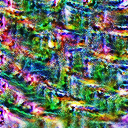

In [44]:
# The default is optimizing for a channel/filter
obj = objectives.channel("layer3_1_conv2", 10)
# Added show_inline=True to display the visualization
_ = render.render_vis(unlearned_model, obj, show_inline=True)

### Parameterizations

For an initial attempt at feature visualization, we might do gradient descent in the pixel space of a randomly initialized image. Unfortunately, this often creates images comprising high frequency noise, similar to [adversarial images](https://arxiv.org/abs/1312.6199).

Instead, the use of alternative parameterizations can produce more visually intuitive results, by operating in the frequency domain or using compositional pattern producing networks.

Recomended reading: Distill's Feature Visualization article, specifically the section on [Preconditioning and Parameterization](https://distill.pub/2017/feature-visualization/#preconditioning)

100%|██████████| 512/512 [02:29<00:00,  3.41it/s]



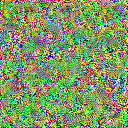

In [45]:
# A visualization with gradient descent in pixel space
# Notice the high frequency components similar to adversarial images

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def param_f():
    # Use the correct parameterization function
    params, image_f = param.image(128, fft=False, decorrelate=False)
    return params, lambda: image_f().to(device)

# We set transforms=[] to denote no transforms
original_model.to(device).eval()
# Try a different layer that was successfully visualized
# Added show_inline=True to display the visualization
obj = objectives.channel("layer3_1_conv2", 0) # Using channel 0 as an example
_ = render.render_vis(original_model, obj, param_f, transforms=[], show_inline=True)

100%|██████████| 512/512 [02:35<00:00,  3.29it/s]



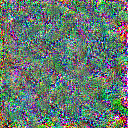

In [46]:
# A visualization with gradient descent in pixel space
# Notice the high frequency components similar to adversarial images

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def param_f():
    # Use the correct parameterization function
    params, image_f = param.image(128, fft=False, decorrelate=False)
    return params, lambda: image_f().to(device)

# We set transforms=[] to denote no transforms
unlearned_model.to(device).eval()
# Try a different layer that was successfully visualized
# Added show_inline=True to display the visualization
obj = objectives.channel("layer3_1_conv2", 0) # Using channel 0 as an example
_ = render.render_vis(unlearned_model, obj, param_f, transforms=[], show_inline=True)

100%|██████████| 512/512 [02:28<00:00,  3.45it/s]



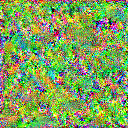

In [47]:
# A visualization with gradient descent in Fourier basis

param_f = lambda: param.image(128, fft=True, decorrelate=False)
# Added show_inline=True to display the visualization
_ = render.render_vis(original_model, obj, param_f, transforms=[], show_inline=True)

100%|██████████| 512/512 [02:31<00:00,  3.38it/s]



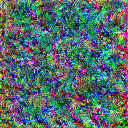

In [48]:
# A visualization with gradient descent in Fourier basis

param_f = lambda: param.image(128, fft=True, decorrelate=False)
# Added show_inline=True to display the visualization
_ = render.render_vis(unlearned_model, obj, param_f, transforms=[], show_inline=True)

100%|██████████| 512/512 [02:28<00:00,  3.44it/s]



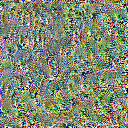

In [49]:
# A visualization with channel decorrelation

param_f = lambda: param.image(128, fft=False, decorrelate=True)
# Added show_inline=True to display the visualization
_ = render.render_vis(original_model, obj, param_f, transforms=[], show_inline=True)

100%|██████████| 512/512 [02:29<00:00,  3.41it/s]



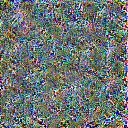

In [50]:
# A visualization with channel decorrelation

param_f = lambda: param.image(128, fft=False, decorrelate=True)
# Added show_inline=True to display the visualization
_ = render.render_vis(unlearned_model, obj, param_f, transforms=[], show_inline=True)

Visualizing classes before and after unlearning (we removed 4500 samples)

In [51]:
def visualize_class(class_idx, original_model, steps=512, show=True):
    from lucent.optvis import objectives
    from lucent.optvis import param, render
    import numpy as np # Import numpy

    obj = objectives.channel("fc", class_idx)
    param_f = lambda: param.image(128)
    # Modified to unpack only the image result
    results = render.render_vis(original_model, obj, param_f,
                                         show_image=False)

    # Assuming render_vis returns a list containing a NumPy array
    # Remove batch dimension if it exists and ensure correct shape for imshow
    result_image_np = results[0]
    if result_image_np.ndim == 4 and result_image_np.shape[0] == 1:
        result_image_np = result_image_np.squeeze(0)

    # Ensure shape is (H, W, C) for matplotlib
    # If the shape is (C, H, W), transpose it
    if result_image_np.ndim == 3 and result_image_np.shape[0] == 3: # Assuming 3 channels for color
         result_image_np = np.transpose(result_image_np, (1, 2, 0))


    # Score calculation is removed for now to fix the unpacking error
    # If score is needed, it might need to be calculated manually or obtained differently

    if show:
        plt.imshow(result_image_np)
        plt.title(f"Class {class_idx}") # Removed score from title
        plt.axis("off")
        plt.show()
    # Returning the processed numpy array and None for score
    return result_image_np, None

Compare multiple classes before and after

100%|██████████| 512/512 [03:24<00:00,  2.50it/s]


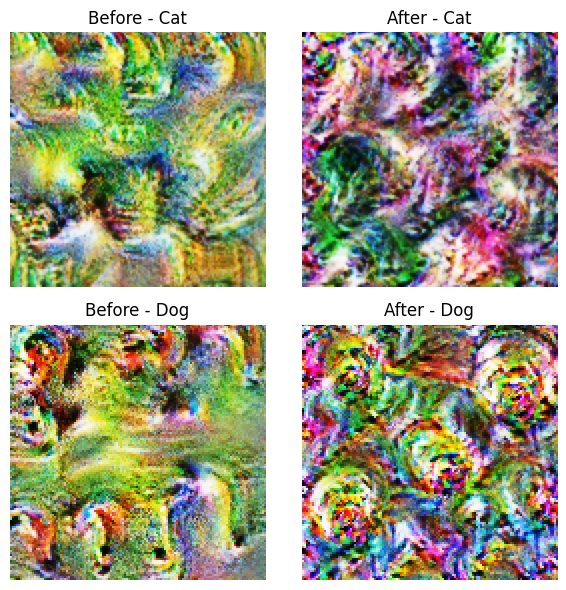

In [52]:
classes_to_check = [3, 5]
fig, axes = plt.subplots(len(classes_to_check), 2, figsize=(6, 6))

for i, class_idx in enumerate(classes_to_check):
    img_pre, score_pre = visualize_class(class_idx, original_model, show=False)
    img_post, score_post = visualize_class(class_idx, unlearned_model, show=False)

    axes[i, 0].imshow(img_pre)
    axes[i, 0].set_title(f"Before - {'Cat' if class_idx == 3 else 'Dog'}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(img_post)
    axes[i, 1].set_title(f"After - {'Cat' if class_idx == 3 else 'Dog'}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

# Even though it’s designed to forget, SalUn (especially with RL and weight masking) can indirectly:

  Remove noisy gradient paths

  Reduce overfitting to specific samples

  Smooth out parts of the network

  Result: the model's internal features become more “general” or well-formed — leading Lucent to converge on more coherent patterns.
Removing 4,500 samples might:

  Eliminate outliers or noisy labels

  Simplify decision boundaries

  Reduce the influence of mislabeled or hard-to-fit examples

  This can improve general feature clarity — especially in overparameterized networks like ResNet-18.
